In [14]:
# Make data for learning analysis

import os
import sys
import pandas as pd
import yaml 
from matplotlib import pyplot as plt
from matplotlib import ticker as mticker
from matplotlib import colors as mcolors
from matplotlib import patches as mpatches
import statsmodels.api as sm
import numpy as np
from itertools import product
import subprocess

np.seterr(divide='ignore', invalid='ignore') # ignore divide by zero warnings

plt.rcParams['font.family'] = 'Times New Roman'
plt.rcParams['font.size'] = 11
#plt.rcParams['text.usetex'] = True

from sklearn.decomposition import PCA

with open("../../config.yaml.local", "r") as f:
    LOCAL_CONFIG = yaml.safe_load(f)
with open("../../config.yaml", "r") as f:
    CONFIG = yaml.safe_load(f)
sys.path.append("../python")

import globals
import data_tools as dt
import writing_tools as wt
import utils
#import emb

LOCAL_PATH = LOCAL_CONFIG["LOCAL_PATH"]
RAW_DATA_PATH = LOCAL_CONFIG["RAW_DATA_PATH"]
DATA_PATH = LOCAL_CONFIG["DATA_PATH"]
R_PATH = LOCAL_CONFIG["R_PATH"]

RUN_R_SCRIPTS = False
REPLACE_ANALYSIS_DATA = False

ANALYSIS_DATA_FILEPATH = os.path.join(DATA_PATH, "learning_analysis_data.parquet")


In [15]:
# Get analysis data
#
# Important columns:
# - userId, created_at, sats48, num_words, num_img_or_links, is_link_post
#
# Each row is a post

df = dt.get_post_quality_analysis_data()
df = df.loc[df['title'] != 'deleted by author'].reset_index(drop=True)

c:\Users\edwar\projects\sn-research\src\notebooks\../python\data_tools.py:91: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  return x.dt.to_period('W-SAT').dt.start_time
c:\Users\edwar\projects\sn-research\src\notebooks\../python\data_tools.py:91: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  return x.dt.to_period('W-SAT').dt.start_time


In [16]:
# bin post types into 5 categories:
# 0. Link posts with no text
# 1. Posts with below median words, no images and links in text body
# 2. Posts with above median words, no images and links in text body
# 3. Posts with below median words, images and links in text body
# 4. Posts with above median words, images and links in text body

df['post_type'] = 0

median_words = df.loc[df['num_words']>0, 'num_words'].median()

df.loc[ df['is_link_post'] & (df['num_words']==0), 'post_type'] = 0
df.loc[ (df['num_words']>0) & (df['num_words']<=median_words) & (df['num_img_or_links']==0), 'post_type'] = 1
df.loc[ (df['num_words']>0) & (df['num_words']<=median_words) & (df['num_img_or_links']>0), 'post_type'] = 2
df.loc[ (df['num_words']>0) & (df['num_words']>median_words) & (df['num_img_or_links']==0), 'post_type'] = 3
df.loc[ (df['num_words']>0) & (df['num_words']>median_words) & (df['num_img_or_links']>0), 'post_type'] = 4

categories = sorted(df['post_type'].unique().tolist())   # list of categories
users = df['userId'].unique().tolist()                   # list of users

category_labels = {
    0: "Link-only posts with no post body text", 
    1: r"$\leq$Median words, no images or links in post body", 
    2: r"$\leq$Median words, images or links in post body",
    3: r"$>$Median words, no images or links in post body",
    4: r"$>$Median words, images or links in post body"
}


In [17]:
# latex summary table

header = r"""\begin{table}[H]
\centering
\caption{Post Types Summary}
\vspace{0.2cm}
\label{tbl_post_types_summary}
\begin{adjustbox}{max width=\textwidth}
\begin{threeparttable}
\begin{tabular}{lrrr}
\toprule
& \makecell{Number\\of posts} & \makecell{Avg. sats\\received in\\first 48 hours} & \makecell{Avg. replies\\received in\\first 48 hours} \\ \midrule
& & & \\
"""
footer = r"""
& & & \\
\bottomrule
\end{tabular}
\begin{tablenotes}
\item {\textit{Notes: } This table reports the number of posts and the average amount of sats and replies received in the first 48 hours, for each post type.}
\end{tablenotes}
\end{threeparttable}
\end{adjustbox}
\end{table}
"""

tbl = ""
for c in categories:
    tbl += f"{category_labels[c]}"
    tbl += f" & {(df['post_type']==c).sum():,.0f}"
    tbl += f" & {df.loc[df['post_type']==c, 'sats48'].mean():,.0f}"
    tbl += f" & {df.loc[df['post_type']==c, 'comments48'].mean():,.1f}"
    tbl += r" \\ [1ex]" + "\n"

print(header + tbl + footer)

with open(os.path.join(LOCAL_PATH, "results", "tbl_post_types_summary.tex"), "w") as f:
    f.write(header + tbl + footer)



\begin{table}[H]
\centering
\caption{Post Types Summary}
\vspace{0.2cm}
\label{tbl_post_types_summary}
\begin{adjustbox}{max width=\textwidth}
\begin{threeparttable}
\begin{tabular}{lrrr}
\toprule
& \makecell{Number\\of posts} & \makecell{Avg. sats\\received in\\first 48 hours} & \makecell{Avg. replies\\received in\\first 48 hours} \\ \midrule
& & & \\
Link-only posts with no post body text & 90,154 & 167 & 1.3 \\ [1ex]
$\leq$Median words, no images or links in post body & 19,385 & 296 & 5.1 \\ [1ex]
$\leq$Median words, images or links in post body & 23,517 & 271 & 3.1 \\ [1ex]
$>$Median words, no images or links in post body & 19,172 & 564 & 6.8 \\ [1ex]
$>$Median words, images or links in post body & 23,629 & 1,112 & 6.9 \\ [1ex]

& & & \\
\bottomrule
\end{tabular}
\begin{tablenotes}
\item {\textit{Notes: } This table reports the number of posts and the average amount of sats and replies received in the first 48 hours, for each post type.}
\end{tablenotes}
\end{threeparttable}
\end{a

In [18]:
# further data prep

df = df.sort_values(by='created_at', ascending=True).reset_index(drop=True)  # sort by timestamp

df['lnsats48'] = np.log1p(df['sats48'])  # log transform sats48

df['ones'] = 1 # create a column of ones


# for each category c, create a column for lnsats48_{c} and is_cat_{c}
# lnsats48_{c} is lnsats48 for posts of category c and zero otherwise
# is_cat_{c} is 1 for posts of category c and zero otherwise
for c in categories:
    df[f'lnsats48_{c}'] = 0.0
    df[f'is_cat_{c}'] = 0
    df.loc[df['post_type']==c, f'lnsats48_{c}'] = df.loc[df['post_type']==c, 'lnsats48']
    df.loc[df['post_type']==c, f'is_cat_{c}'] = 1
    df[f'cum_sum_lnsats48_{c}'] = df[f'lnsats48_{c}'].shift(1).cumsum()  # cumulative sum of lnsats48 for category c posts up to but not including current post
    df[f'cum_count_{c}'] = df[f'is_cat_{c}'].shift(1).cumsum()  # cumulative count of all category c posts up to but not including current post


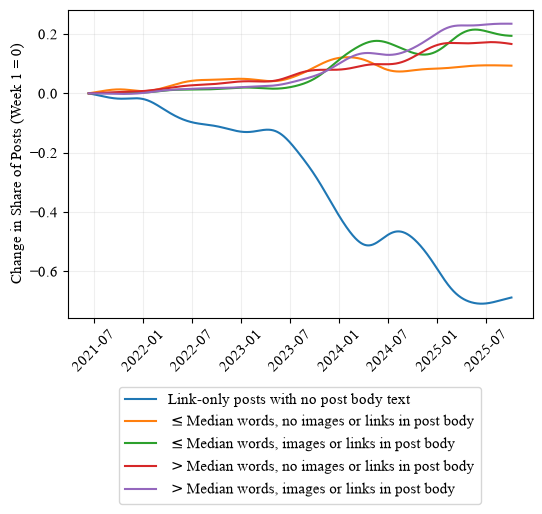

In [51]:
T0 = df['created_at'].min()
X = np.array((df['created_at'] - T0) / pd.Timedelta(days=1))
GRID = np.linspace(X.min(), X.max(), 1000)
TGRID = T0 + GRID*pd.Timedelta(days=1)
bw = 60 # days

plt.figure(figsize=(6, 4))
y = {}
for c in categories:
    Y = df[f'is_cat_{c}'].to_numpy()
    y[c], _, _ = utils.weighted_kreg(X, Y, df['ones'].to_numpy(), bw, GRID, nboot=0)
    plt.plot(TGRID, y[c] - y[c][0], label=category_labels[c])
plt.xticks(rotation=45)
plt.grid(alpha=0.2)
plt.ylabel('Change in Share of Posts (Week 1 = 0)')
plt.legend(loc='upper center', bbox_to_anchor=(0.5, -0.2))

plt.savefig(os.path.join(LOCAL_PATH, "results", "fig_v4v_q_trend.pdf"), bbox_inches='tight')

tex = r"""
\begin{figure}[H]
\caption{Change in Post Composition Over Time} \label{fig_v4v_q_trend}
\vspace{-0.8cm}
\begin{center}
\begin{adjustbox}{width=\textwidth}
\includegraphics{results/fig_v4v_q_trend.pdf}
\end{adjustbox}
\end{center}
\vspace{-0.5cm}
\footnotesize \textit{Note:} Shows how the share of each type of post changed since the first week. See Section \ref{sec_v4v} for a more detailed description of each post type. 
\end{figure}
"""
with open(os.path.join(LOCAL_PATH, "results", "fig_v4v_q_trend.tex"), "w") as f:
    f.write(tex)


In [7]:
# mapping of user ids to index of user's first post
user_first_post_idx = {}
for u in users:
    user_first_post_idx[u] = df.loc[df['userId']==u].index[0]

In [8]:
# cum_avg_lnsats48_{c}:
#     For each user i and each category c, the average lnsats48 for all category c posts posted between user i's first appearance date and the current post
#
# i.e. Information set is all posts between the user's first post and the current post

for c in categories:
    df[f'cum_avg_lnsats48_{c}'] = np.nan
    df[f'cum_avg_lnsats48_u_{c}'] = np.nan

for i, u in enumerate(users):
    user_posts = df.loc[df['userId']==u].index
    first_post_idx = user_first_post_idx[u]
    n = len(df)
    selection_mask = (df['created_at'] >= df.loc[first_post_idx, 'created_at']).to_numpy()
    selection_mask_u = ((df['created_at'] >= df.loc[first_post_idx, 'created_at']) & (df['userId']==u)).to_numpy()
    for c in categories:
        lnsats48 = df[f'lnsats48_{c}'].to_numpy() * selection_mask
        is_cat = df[f'is_cat_{c}'].to_numpy() * selection_mask
        numer = np.concat([[np.nan], lnsats48[0:n-1].cumsum()])
        denom = np.concat([[np.nan], is_cat[0:n-1].cumsum()])
        df.loc[user_posts, f'cum_avg_lnsats48_{c}'] = numer[user_posts] / denom[user_posts]

        lnsats48_u = df[f'lnsats48_{c}'].to_numpy() * selection_mask_u
        is_cat_u = df[f'is_cat_{c}'].to_numpy() * selection_mask_u
        numer_u = np.concat([[np.nan], lnsats48_u[0:n-1].cumsum()])
        denom_u = np.concat([[np.nan], is_cat_u[0:n-1].cumsum()])
        df.loc[user_posts, f'cum_avg_lnsats48_u_{c}'] = numer_u[user_posts] / denom_u[user_posts]


In [9]:
# cum_avg_lnsats48_recent_{c}:
#     For each user i and each category c, the average lnsats48 for all category c posts posted before the current post,
#     weighted by recency decay
#
# i.e. Information set is all posts before the current post, with weights decaying exponentially in time

half_life = pd.Timedelta(days=28)
decay_lambda = np.log(2) / half_life.total_seconds()

for c in categories:
    df[f'cum_avg_lnsats48_recent_{c}'] = np.nan
    df[f'cum_avg_lnsats48_recent_u_{c}'] = np.nan

numer = {}   # running weighted sum of lnsats48 by category
denom = {}   # running sum of weights by category
last_t = {}  # running last timestamp by category
for c in categories:
    numer[c] = 0
    denom[c] = 0
    last_t[c] = 0

numer_u = {}   # running weighted sum of lnsats48 by user/category
denom_u = {}   # running sum of weights by user/category
last_t_u = {}  # running last timestamp by user/category
for u in users:
    for c in categories:
        numer_u[(u,c)] = 0
        denom_u[(u,c)] = 0
        last_t_u[(u,c)] = 0

for idx, row in df.iterrows():
    u = row['userId']
    curr_post_time = row['created_at']
    for c in categories:
        # since averages don't include current post, check current running numer and denom
        if denom[c] > 0:
            df.loc[idx, f'cum_avg_lnsats48_recent_{c}'] = numer[c] / denom[c]
            dt = (curr_post_time - last_t[c]).total_seconds()
            decay = np.exp(-decay_lambda * dt)
            numer[c] = decay * numer[c] + row[f'lnsats48_{c}']
            denom[c] = decay * denom[c] + row[f'is_cat_{c}']
            last_t[c] = curr_post_time
        else:
            numer[c] = row[f'lnsats48_{c}']
            denom[c] = row[f'is_cat_{c}']
            last_t[c] = curr_post_time
        
        if denom_u[(u,c)] > 0:
            df.loc[idx, f'cum_avg_lnsats48_recent_u_{c}'] = numer_u[(u,c)] / denom_u[(u,c)]
            dt_u = (curr_post_time - last_t_u[(u,c)]).total_seconds()
            decay_u = np.exp(-decay_lambda * dt_u)
            numer_u[(u,c)] = decay_u * numer_u[(u,c)] + row[f'lnsats48_{c}']
            denom_u[(u,c)] = decay_u * denom_u[(u,c)] + row[f'is_cat_{c}']
            last_t_u[(u,c)] = curr_post_time
        else:
            numer_u[(u,c)] = row[f'lnsats48_{c}']
            denom_u[(u,c)] = row[f'is_cat_{c}']
            last_t_u[(u,c)] = curr_post_time


In [10]:
# cum_avg_lnsats48_user_{c}:
#     For each user i and each category c, the average lnsats48 for all category c posts posted by user i, up to the current post
#
# i.e. Information set is the user's own posts

for c in categories:
    df[f'cum_avg_lnsats48_user_{c}'] = np.nan

for i, u in enumerate(users):
    user_posts = df.loc[df['userId']==u].index
    n = len(user_posts)
    for c in categories:
        lnsats48 = df.loc[user_posts, f'lnsats48_{c}'].to_numpy()
        is_cat = df.loc[user_posts, f'is_cat_{c}'].to_numpy()
        numer = np.concat([[np.nan], lnsats48[0:n-1].cumsum()])
        denom = np.concat([[np.nan], is_cat[0:n-1].cumsum()])
        df.loc[user_posts, f'cum_avg_lnsats48_user_{c}'] = numer / denom


In [11]:
# cum_avg_lnsats48_activity_{c}:
#     For each user i and each category c, the average lnsats48 for all category c posts posted between user i's first appearance date and the current post,
#     weighted by proximity to user's peak activity hours
#
# i.e. Information set is all posts between user's first post and the current post, weighted by proximity to user's peak activity hours

PERIOD = 24*3600
HALF_LIFE = 3*3600
SIGMA = HALF_LIFE / np.log(2)

post_times = (df['created_at'].dt.hour * 3600 + df['created_at'].dt.minute * 60 + df['created_at'].dt.second).astype(float).to_numpy()

user_peak_times = {}
for i, u in enumerate(users):
    user_posts = df.loc[df['userId']==u].index
    user_peak_times[u] = post_times[user_posts].mean()

for c in categories:
    df[f'cum_avg_lnsats48_activity_{c}'] = np.nan
    df[f'cum_avg_lnsats48_activity_u_{c}'] = np.nan

for i, u in enumerate(users):
    user_posts = df.loc[df['userId']==u].index
    first_post_idx = user_first_post_idx[u]
    n = len(df)
    selection_mask = (df['created_at'] >= df.loc[first_post_idx, 'created_at']).to_numpy()
    selection_mask_u = ((df['created_at'] >= df.loc[first_post_idx, 'created_at']) & (df['userId']==u)).to_numpy()
    peak_time = user_peak_times[u]
    time_diffs = peak_time - post_times
    time_diffs = (time_diffs + PERIOD/2) % PERIOD - PERIOD/2
    weights = np.exp(-(time_diffs/SIGMA)**2)
    
    for c in categories:
        lnsats48 = df[f'lnsats48_{c}'].to_numpy() * selection_mask * weights
        is_cat = df[f'is_cat_{c}'].to_numpy() * selection_mask * weights
        numer = np.concat([[np.nan], lnsats48[0:n-1].cumsum()])
        denom = np.concat([[np.nan], is_cat[0:n-1].cumsum()])
        df.loc[user_posts, f'cum_avg_lnsats48_activity_{c}'] = numer[user_posts] / denom[user_posts]

        lnsats48_u = df[f'lnsats48_{c}'].to_numpy() * selection_mask_u * weights
        is_cat_u = df[f'is_cat_{c}'].to_numpy() * selection_mask_u * weights
        numer_u = np.concat([[np.nan], lnsats48_u[0:n-1].cumsum()])
        denom_u = np.concat([[np.nan], is_cat_u[0:n-1].cumsum()])
        df.loc[user_posts, f'cum_avg_lnsats48_activity_u_{c}'] = numer_u[user_posts] / denom_u[user_posts]


In [12]:
# construct long dataframe for conditional logit

df = df.sort_values(by=['userId', 'created_at']).reset_index(drop=True)
df['experience_posts'] = df.groupby('userId').cumcount()
df['experience_days'] = (df['created_at'] - df.groupby('userId')['created_at'].transform('min')) / pd.Timedelta(days=1)

long_df = {
    'userId': [], 'timestamp': [], 'itemId': [], 'weekId': [], 'subId': [], 
    'choice': [], 'post_type': [], 'chosen': [], 'experience_posts': [], 'experience_days': [],
    'cum_avg_lnsats48': [], 'cum_avg_lnsats48_recent': [], 'cum_avg_lnsats48_user': [], 'cum_avg_lnsats48_activity': [],
    'cum_avg_lnsats48_u': [], 'cum_avg_lnsats48_recent_u': [], 'cum_avg_lnsats48_activity_u': []
}

cols = []
for c in categories:
    cols = cols + [
        f'cum_avg_lnsats48_{c}', f'cum_avg_lnsats48_u_{c}', 
        f'cum_avg_lnsats48_recent_{c}', f'cum_avg_lnsats48_recent_u_{c}',
        f'cum_avg_lnsats48_activity_{c}', f'cum_avg_lnsats48_activity_u_{c}',
        f'cum_avg_lnsats48_user_{c}'
    ]

for idx, row in df.iterrows():
    u = row['userId']
    t = row['created_at']
    choice = row['post_type']

    # skip if any missing values
    if row[cols].isna().any():
        continue

    for c in categories:
        long_df['userId'].append(u)
        long_df['timestamp'].append(t)
        long_df['itemId'].append(row['itemId'])
        long_df['weekId'].append(row['weekId'])
        long_df['subId'].append(row['subId'])
        long_df['choice'].append(choice)
        long_df['post_type'].append(c)
        long_df['chosen'].append(c==choice)
        long_df['experience_posts'].append(row['experience_posts'])
        long_df['experience_days'].append(row['experience_days'])
        long_df['cum_avg_lnsats48'].append(row[f'cum_avg_lnsats48_{c}'])
        long_df['cum_avg_lnsats48_recent'].append(row[f'cum_avg_lnsats48_recent_{c}'])
        long_df['cum_avg_lnsats48_user'].append(row[f'cum_avg_lnsats48_user_{c}'])
        long_df['cum_avg_lnsats48_activity'].append(row[f'cum_avg_lnsats48_activity_{c}'])
        long_df['cum_avg_lnsats48_u'].append(row[f'cum_avg_lnsats48_u_{c}'])
        long_df['cum_avg_lnsats48_recent_u'].append(row[f'cum_avg_lnsats48_recent_u_{c}'])
        long_df['cum_avg_lnsats48_activity_u'].append(row[f'cum_avg_lnsats48_activity_u_{c}'])

long_df = pd.DataFrame(long_df)

long_df.to_parquet(ANALYSIS_DATA_FILEPATH)
